<h1>Video Game Sales Data Exploratory Analysis</h1>

These are the two datasets that will be used within this investigation, both can be found on kaggle.com:

The <a href="https://www.kaggle.com/datasets/anandshaw2001/video-game-sales"> video game sales dataset</a> is a dataset of games released within 2006-2020. It is 16598 rows × 11 columns and contains different attributes that describes video games and their sales such as the genre, number of global sales, what platform it was released on etc...

The <a href="https://www.kaggle.com/datasets/deepcontractor/top-video-games-19952021-metacritic"> Metacritic dataset</a> is a dataset of 18800 rows × 6 columns, containing information such as scores and user reviews from a website that reviews video games called Metacritic.


Brief description of all of the variables in the datasets:

Video game sales
- Rank: Rank of the game in terms of sales.
- Name: Name of the video game.
- Platform: Gaming platform (e.g., Wii, NES, GB).
- Year: Release year (some missing values).
- Genre: Game genre (e.g., Sports, Racing, Role-Playing).
- Publisher: Publisher of the game (some missing values).
- NA_Sales, EU_Sales, JP_Sales, Other_Sales, Global_Sales: Sales in different regions (millions of copies).

Metacritic 
- meta_score: Metacritic's score given to the game. 
- user_review: The average of aggregated reviews scores from users who played the game.

This investigation will conduct some preliminary cleaning and exploratory data analysis on the two data sets listed above. The goal is to find interesting insights on video game regional and global sales against other factors like the year of release, the genre of the game and whether things like reviews from journalism sites such as Metacritic or user reviews have a significant affect on the profitability of the game in term of its sales.

<h2>Importing and Cleaning Data</h2>

Importing the datasets

In [6]:
#First import the required python libraries and packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.stats import spearmanr 

In [7]:
sales_df = pd.read_csv("vgsales.csv")
sales_df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [8]:
ratings_df = pd.read_csv("all_games.csv", parse_dates=['release_date'])
ratings_df

,name,platform,release_date,summary,meta_score,user_review
0,The Legend of Zelda: Ocarina of Time,Nintendo 64,1998-11-23,"As a young boy, Link is tricked by Ganondorf, ...",99,9.1
1,Tony Hawk's Pro Skater 2,PlayStation,2000-09-20,As most major publishers' development efforts ...,98,7.4
2,Grand Theft Auto IV,PlayStation 3,2008-04-29,[Metacritic's 2008 PS3 Game of the Year; Also ...,98,7.7
3,SoulCalibur,Dreamcast,1999-09-08,"This is a tale of souls and swords, transcendi...",98,8.4
4,Grand Theft Auto IV,Xbox 360,2008-04-29,[Metacritic's 2008 Xbox 360 Game of the Year; ...,98,7.9
...,...,...,...,...,...,...
18795,Fast & Furious: Showdown,Xbox 360,2013-05-21,Fast & Furious: Showdown takes some of the fra...,22,1.3
18796,Drake of the 99 Dragons,Xbox,2003-11-03,Drake is out for revenge in a supernatural Hon...,22,1.7
18797,Afro Samurai 2: Revenge of Kuma Volume One,PlayStation 4,2015-09-22,"Head out on a journey of redemption, driven by...",21,2.9
18798,Infestation: Survivor Stories (The War Z),PC,2012-10-15,"(Formerly known as ""The War Z"") It has been 5 ...",20,1.7


As shown above the data sets were imported correctly. The vg_sales data contains 16598 rows × 11 columns where the meta critics data set contains 18800 rows × 6 columns

<h4>Cleaning vgsales dataset</h4>

In [11]:
print("Different columns in the data set and their types:")
print(sales_df.dtypes)

Different columns in the data set and their types:
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


In [12]:
print("Checking for missing values:")
print(sales_df.isnull().sum())
print("")

print("Checking for duplicates:")
print(sales_df.duplicated().sum())

Checking for missing values:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

Checking for duplicates:
0


Cleaning the Year column: Dropping missing values and changing the year to an integer instead of float

In [14]:
sales_df[sales_df['Year'].isna()]
sales_df.drop(sales_df[sales_df['Year'].isna()].index, inplace =True)
sales_df['Year'] = sales_df['Year'].astype(int)

Cleaning the Publisher column

In [16]:
sales_df["Publisher"] = sales_df["Publisher"].fillna("Unknown")
print("Missing values")
print(sales_df.isnull().sum())

Missing values
Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


<h4>Cleaning Metacritic dataset</h4>

In [18]:
print("Different columns in the data set and their types:")
print(ratings_df.dtypes)

Different columns in the data set and their types:
name                    object
platform                object
release_date    datetime64[ns]
summary                 object
meta_score               int64
user_review             object
dtype: object


In [19]:
ratings_df['user_review'] = pd.to_numeric(ratings_df['user_review'], errors="coerce")

print("Checking for missing values:")
print(ratings_df.isnull().sum())

print("")
print("Checking for duplicates:")
print(ratings_df.duplicated().sum())

Checking for missing values:
name               0
platform           0
release_date       0
summary          114
meta_score         0
user_review     1365
dtype: int64

Checking for duplicates:
0


In [20]:
ratings_df.drop(ratings_df[ratings_df['user_review'].isnull()].index, inplace =True) #Removing missing values for user_review

<h4>Standardising and Merging the datasets</h4>

In [22]:
sales_df['Name'] = sales_df['Name'].str.strip().str.lower()
ratings_df['name'] = ratings_df['name'].str.strip().str.lower()

In [23]:
print("Checking for duplicate names before merging the datasets:")
print(sales_df.duplicated(subset="Name").sum())
print(ratings_df.duplicated(subset="name").sum())

Checking for duplicate names before merging the datasets:
4967
6061


Both data sets contains duplicate names for various video games. For both vg_sales and the metacritic data set, there are rows with the same game names since the same game can be sold on different platforms and be released at different times. The varying amount of sales of a game based on the platforms. This could skew future analysis especially when using reviews or meta score since one game would be counted multiple times. Additionally, future analysis focuses a lot more on user reviews and metacritic scores of the data, whereas the platform is not utilised as much. Therefore, it is decided that for both data sets, a specific game would only be counted once, the duplicated rows are dropped and the row with the highest global sales/the highest reviews for that specific game is kept. 

In [25]:
ratings_df = ratings_df.sort_values(by="user_review", ascending=False)
ratings_df = ratings_df.drop_duplicates(subset="name", keep="first")
sales_df = sales_df.drop_duplicates(subset="Name", keep="first")

In [26]:
df = pd.merge(sales_df, ratings_df, how='left', left_on='Name', right_on='name')

In [27]:
print("Checking the summary statistics:")
df.describe()

Checking the summary statistics:


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,release_date,meta_score,user_review
count,11360.000000,11360.000000,11360.000000,11360.000000,11360.000000,11360.000000,11360.000000,4470,4470.000000,4470.000000
mean,8288.805546,2005.636796,0.285571,0.158296,0.105065,0.051033,0.600180,2007-07-03 22:00:09.664429568,70.730201,7.484519
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,1996-03-30 00:00:00,22.000000,1.300000
25%,3947.750000,2002.000000,0.000000,0.000000,0.000000,0.000000,0.060000,2004-02-10 00:00:00,63.000000,7.000000
50%,8323.500000,2007.000000,0.070000,0.020000,0.000000,0.010000,0.170000,2007-05-08 00:00:00,73.000000,7.800000
75%,12640.250000,2010.000000,0.240000,0.110000,0.060000,0.030000,0.510000,2010-06-29 00:00:00,81.000000,8.300000
max,16599.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000,2021-07-27 00:00:00,99.000000,9.700000
std,4919.541621,6.093567,0.943103,0.574686,0.365880,0.215387,1.796942,NaN,13.560854,1.231067


In [28]:
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,name,platform,release_date,summary,meta_score,user_review
0,1,wii sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,wii sports,Wii,2006-11-19,Tennis (1-4 players): Players grab the control...,76.0,8.1
1,2,super mario bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaT,NaN,NaN,NaN
2,3,mario kart wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,mario kart wii,Wii,2008-04-27,Mario Kart Wii comes with the intuitive Wii Wh...,82.0,8.4
3,4,wii sports resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,wii sports resort,Wii,2009-07-26,Wii Sports Resort is a collection of fun sport...,80.0,8.2
4,5,pokemon red/pokemon blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11355,16592,chou ezaru wa akai hana: koi wa tsuki ni shiru...,PSV,2016,Action,dramatic create,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaT,NaN,NaN,NaN
11356,16593,eiyuu densetsu: sora no kiseki material collec...,PSP,2007,Role-Playing,Falcom Corporation,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaT,NaN,NaN,NaN
11357,16595,plushees,DS,2008,Simulation,Destineer,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaT,NaN,NaN,NaN
11358,16596,woody woodpecker in crazy castle 5,GBA,2002,Platform,Kemco,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaT,NaN,NaN,NaN


In [29]:
print(df.isnull().sum())

Rank               0
Name               0
Platform           0
Year               0
Genre              0
Publisher          0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Other_Sales        0
Global_Sales       0
name            6890
platform        6890
release_date    6890
summary         6895
meta_score      6890
user_review     6890
dtype: int64


There are some games that are listed on one dataset but not the other; this mismatch does lead to a significant proportion of the games having NaN values for user_review and meta_score. However, the rest of the the data is still significant, therefore, this dataframe will be kept like this and any visualisations that specifically filters on user_review or meta_score will be cleaned seperately. 

<h2>Visualising the Data</h2>

<h3>Analysis of the Distribution of Different Variables</h3>

This section aims to give an idea how the numerical variables are distributed which is important to take into consideration when drawing conclusions from visualisations of the data later on. This is done using various box plots and histograms. 

<h4>Box Plots and Histograms - How are the numerical variables such as of Video Game Sales, Metacritic Score and User Review Score Distributed?</h4>

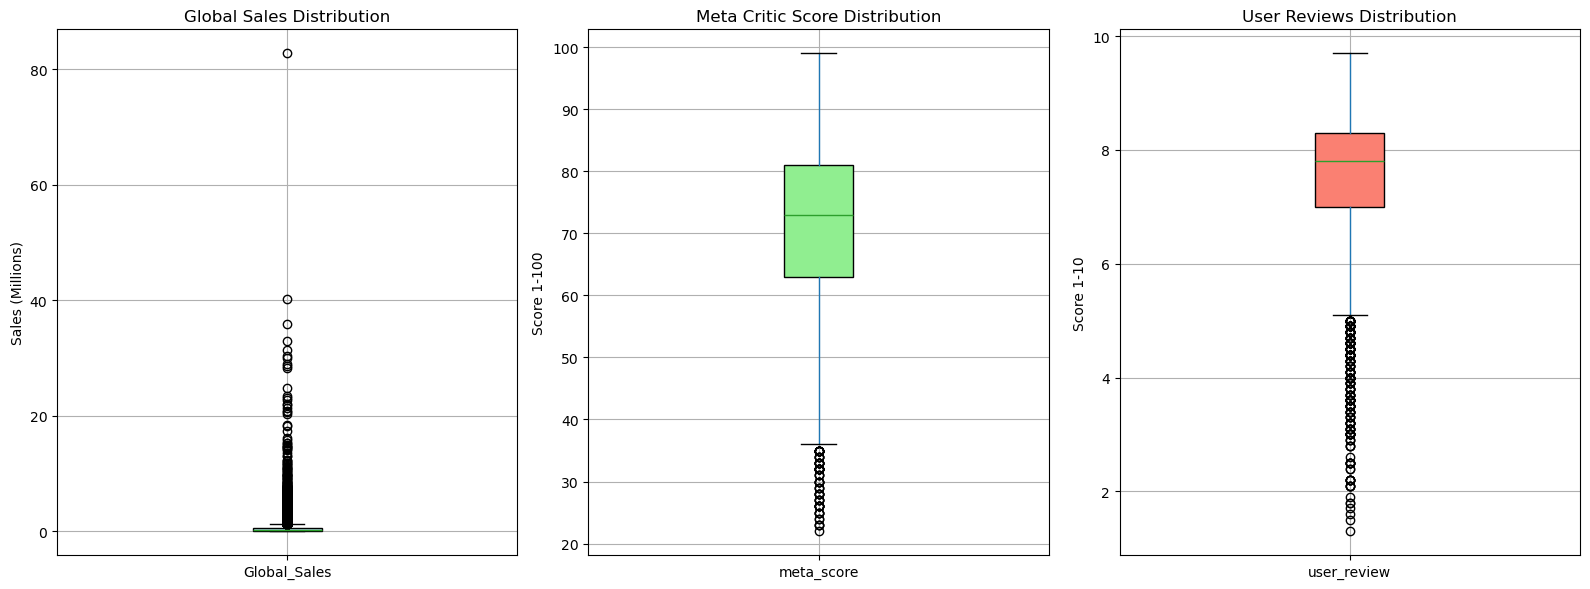

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16,6))

df.boxplot(ax=axes[0], column='Global_Sales', patch_artist=True, 
            boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Global Sales Distribution')
axes[0].set_ylabel('Sales (Millions)')

df.boxplot(ax=axes[1], column='meta_score', patch_artist=True, 
            boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('Meta Critic Score Distribution')
axes[1].set_ylabel('Score 1-100')

df.boxplot(ax=axes[2], column='user_review', patch_artist=True, 
            boxprops=dict(facecolor='salmon'))
axes[2].set_title('User Reviews Distribution')
axes[2].set_ylabel('Score 1-10')


plt.tight_layout()
plt.show()

The plots above are the boxplots showing the distribution for global sales, meta critic scores and user reviews of the games. With global sales, the distribution is highly right-skewed with a large number of low-selling games under 5 million sales and a few large outliers with over 20 to 80 million copies sold. On the other hand, Metacritic scores are normally distributed around the median of 72 and interquartile range (IQR) of around 64 to 80. There are some outliers that are lower than 40. User reviews is distributed similarly with median of roughly 7.8 and IQR of 7.2 to 8.2. 

- Overall, both critic and user scores are generally positive, with a majority of games achieving decent to strong ratings.

- The video game market is dominated by a few massively successful titles in terms of sales and the rest and signifincatly lower selling games comparatively. 

- The generally high ratings, and lower sales for most games does explain the weaker correlation between global sales and metacritic scores/user reivews. The presence of outliers also highlights the varied performance and reception games receive, supports the fact that many factors contribute to both critical acclaim and commercial success; correlation does not mean causation. 

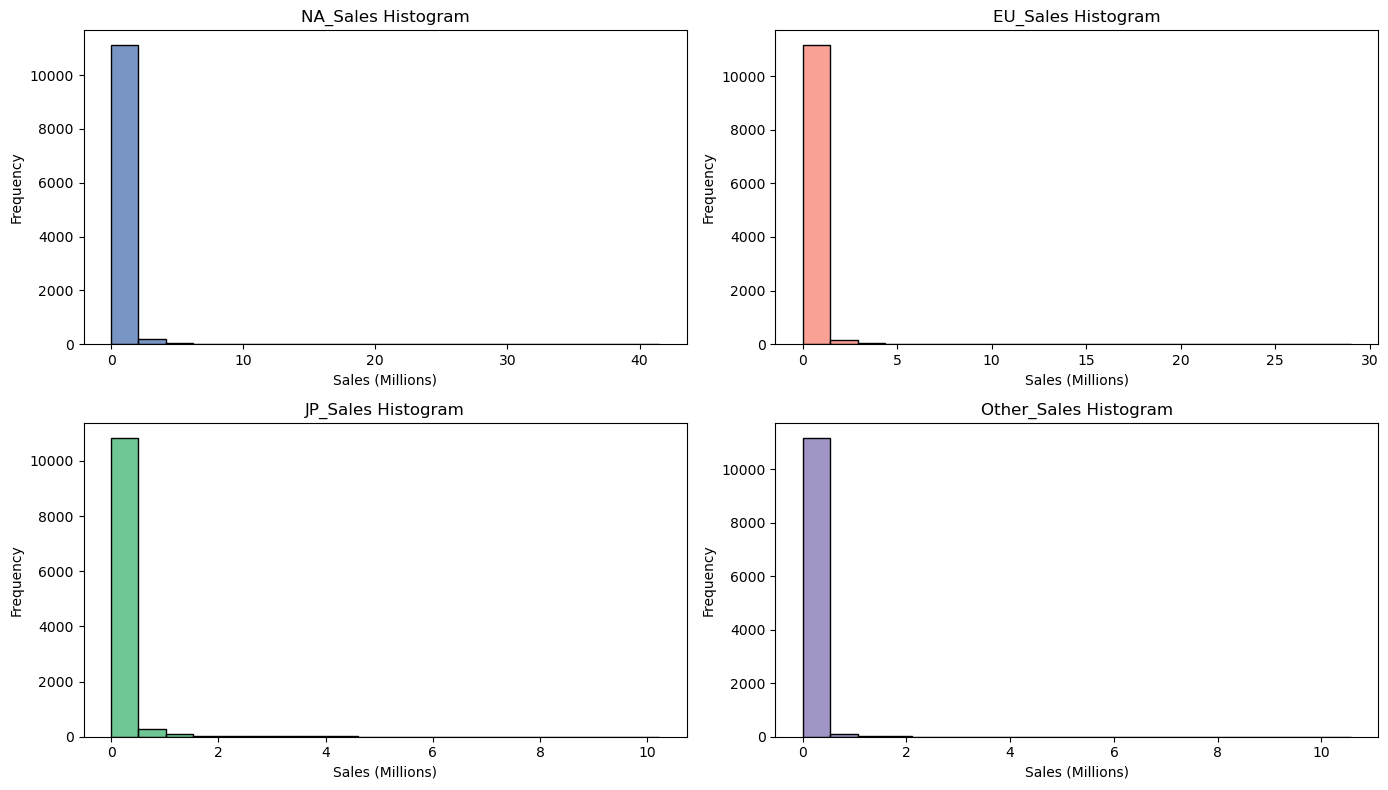

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14,8))
regions = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
colours = ['#4c72b0', 'salmon', 'mediumseagreen', '#8172b2']
axes = axes.flatten()

def plot_histogram(df, region, ax, color):
    sns.histplot(df[region], bins=20, ax=ax, color=color)
    ax.set_title(f'{region} Histogram')
    ax.set_ylabel('Frequency')
    ax.set_xlabel('Sales (Millions)')


for i in range(len(regions)):
    plot_histogram(df, regions[i], axes[i], colours[i])

plt.tight_layout()
plt.show()

The four histograms above describes the distribution for the remaining numeric columns of the dataset: JP, EU, NA and Other Sales. All of these graph's distirbution are very similar; they are all heavily right skewed which aligns with Global Sale's distribution as well. The majority of games in these regions have sales below half a million with some very large outliers that sells significanty more than the median.

<h3>Analysis of Correlational Relationships in the Variables</h3>

This section explores potential linear relationships bewteen the numeric variables using a correlation matrix heat map and scatter plot. The main aim of this section is to explore the how the other numerical variables affect a video game's global sales. An example hypothesis is that that an increase in Metacritic score for a game would result in an increase in global sales. 

<h4>Heatmap -  What is the General Linear Correlation Relationships for the Datasets' Numerical Columns?</h4>

In [42]:
numerical_columns = [n for n,col in df.items() if pd.api.types.is_numeric_dtype(col)]
corr = spearmanr(df[numerical_columns].dropna()).correlation
corr

array([[ 1.        ,  0.01361297, -0.89974675, -0.79402594, -0.4456745 ,
        -0.87544172, -0.9999151 , -0.40601917, -0.24305119],
       [ 0.01361297,  1.        , -0.06985363, -0.0113427 ,  0.13477594,
         0.12308633, -0.01346541, -0.05032001, -0.25060817],
       [-0.89974675, -0.06985363,  1.        ,  0.66418372,  0.2666538 ,
         0.78663992,  0.89966232,  0.33762863,  0.21626342],
       [-0.79402594, -0.0113427 ,  0.66418372,  1.        ,  0.23259752,
         0.81170827,  0.79388131,  0.35223577,  0.19508   ],
       [-0.4456745 ,  0.13477594,  0.2666538 ,  0.23259752,  1.        ,
         0.29123179,  0.4455616 ,  0.26250883,  0.21017105],
       [-0.87544172,  0.12308633,  0.78663992,  0.81170827,  0.29123179,
         1.        ,  0.87535753,  0.34792518,  0.19015571],
       [-0.9999151 , -0.01346541,  0.89966232,  0.79388131,  0.4455616 ,
         0.87535753,  1.        ,  0.40600734,  0.24295797],
       [-0.40601917, -0.05032001,  0.33762863,  0.35223577,  0

Above is the correlation matrix for all of the numeric columns in the dataset, this correlation matrix is visualised in a heatmap for easier analysis below. 

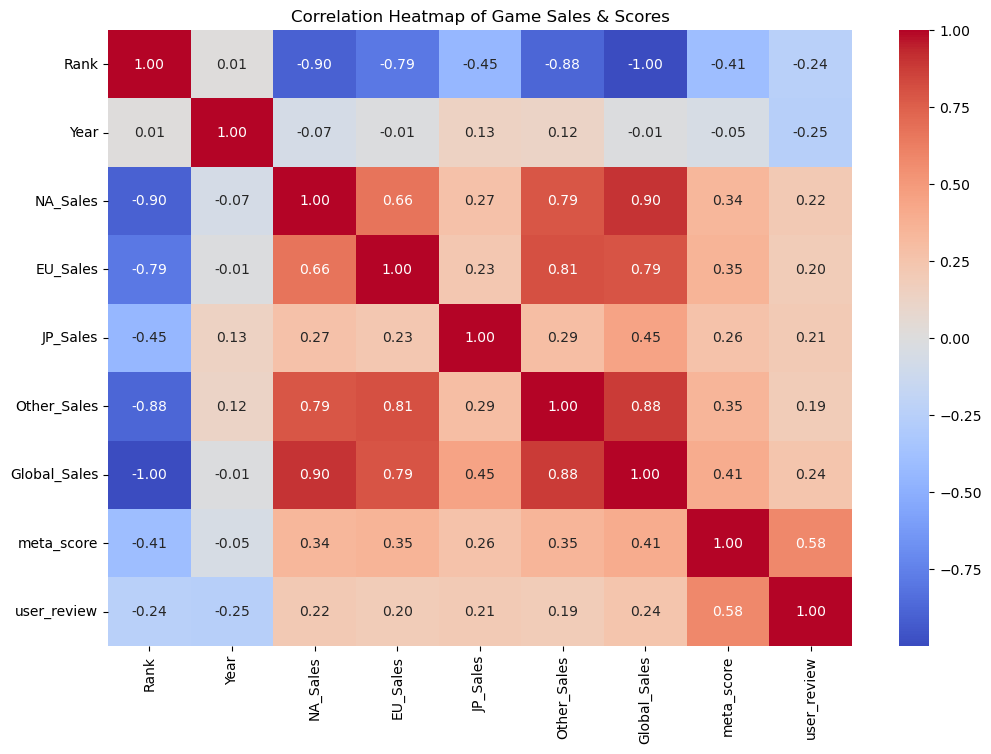

In [44]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', xticklabels=numerical_columns, yticklabels=numerical_columns)
plt.title('Correlation Heatmap of Game Sales & Scores')
plt.show()

The plot is a heatmap showing correlation values between all of the numerical attributes of the combined dataset. Higher correlation values in a tile means a stronger positive linear correlation between the two attributes that intersects that tile and vice versa; warmer colours means higher correlation and bluer colours means lower correlation. The heatmap offers valuable insight into which metrics move together and highlights possible avenues for deeper investigation into the factors influencing video game sales.

- We can see that values such as EU, NA and JP sales have strong correlations with global sales which makes sense. 

- Surprisingly, reviews and scores have a relatively small correlation to sales. This could mean that other factors like marketing, franchise reputation, and platform availability might play a larger role in sales  than critic scores and user reviews alone.
    - Although speculative, this could also suggest that Metacritic's reviews are bias or is not completely accurate


- There is a reasonable correlation between meta score and user review, however, the correlation is not the strongest and there are some discrepancy between Metacritic's score on a game and what users actually rate the game. 

<h4>Scatter plot - Is there a Significant Positive Linear Relationship Between Global Sales and Metacritic Score?</h4>

Slope coefficient: 0.04338843076307718
Y intercept: -2.107351191001689


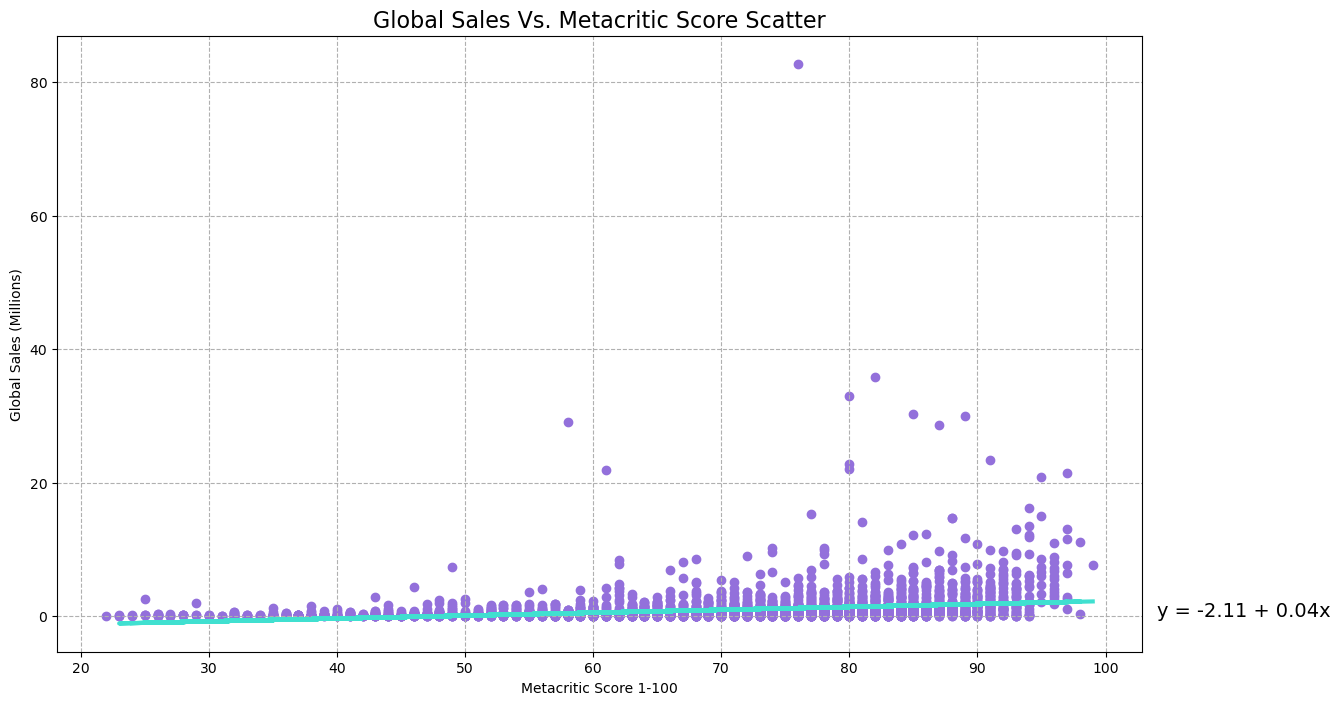

In [47]:
df_scatter = df.dropna(subset=['meta_score'])
a, b = np.polyfit(df_scatter['meta_score'], df_scatter['Global_Sales'], 1)

print("Slope coefficient: " + str(a))
print("Y intercept: " + str(b))

plt.figure(figsize=(14,8))
plt.scatter(df['meta_score'], df['Global_Sales'], color="mediumpurple")

plt.plot(df['meta_score'], df['meta_score']*a+b, color='turquoise', linewidth=3)
plt.text(104, 0, 'y = ' + str(round(b, 2)) + " + " + str(round(a, 2)) + 'x', size=14)

plt.title('Global Sales Vs. Metacritic Score Scatter', fontsize=16)
plt.xlabel('Metacritic Score 1-100')
plt.ylabel('Global Sales (Millions)')
plt.grid(True, linestyle='--')
plt.show()

The plot above shows a scatter plot of the global sales of a game on the y axis and the Metacritic score for that game on the x axis with a linear regression line generated and plotted on the scatter (the line with the teel colour). 

The linear regression model computed by Numpy is 'Global_Sales = -2.11 + 0.04 x meta_score'. Assuming that the coeficients generated by this model is significant, a general interpretation using the predictive model is that:
- For every 1 unit increase in Metacritic's score, we can expect a 0.04 million units of that game sold in global sales on average.
- If the Metacritic score is zero, there will be an expected -2.11 million units in global sales (since it is a linear predictive model this value does not make sense in a real life context)

Both the correlation matrix and the scatter plot regression model suggests that there is a slight positive correlation between Metacritic scores and the global sales of a video game. However, this relationship is shown to be very weak and cannot be used to fully support the hypothesis initially made between Metacritic scores and global sales. Other variables such as advertising budget or the price of the game for example could have a stronger affect on global sales which is not described in the Metacritic score. Additionally, more  research is required to confirm that there is no coufouding factors affecting both Metacritic's scores and global sales. Other complex analysis can also be done to verify the reliability and significance of this linear relationship and the regression model shown.

<h4>Line plot - How Sales Does one Game Get Yearly on Average and How Does that Compare with the Amount of Games Released Yearly?</h4>

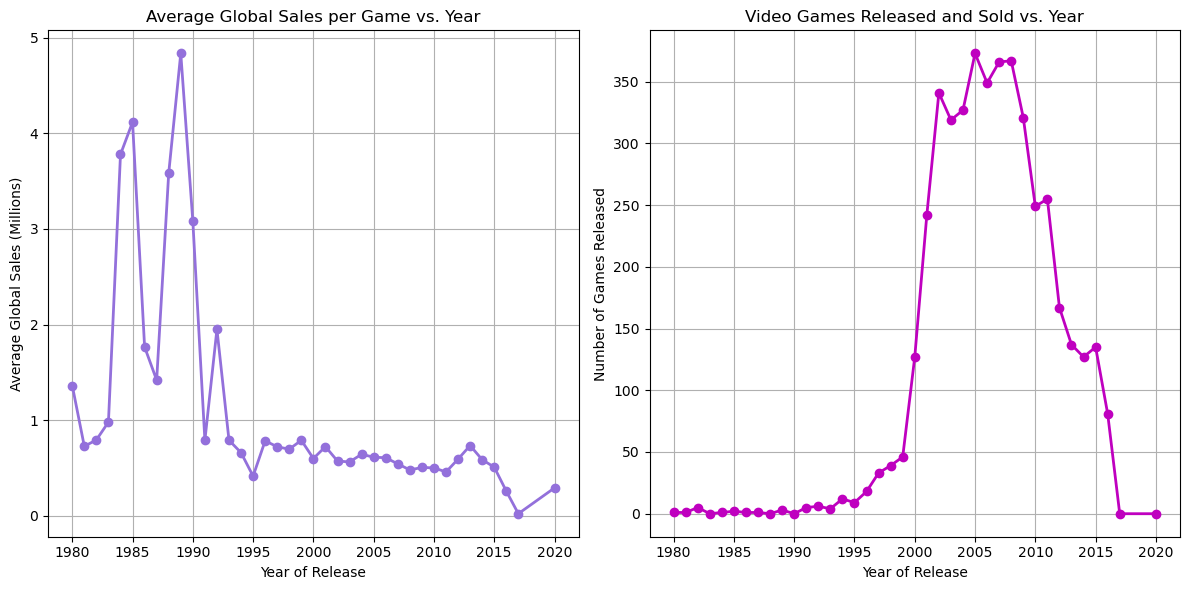

In [50]:
sales_per_year = df.groupby('Year')['Global_Sales'].mean()
games_per_year = df.groupby('Year')['name'].count()

fig, axes = plt.subplots(1, 2, figsize=(12,6))

#plt.figure(figsize=(12,6))
sales_per_year.plot(ax=axes[0], kind='line', marker='o', linewidth=2, color='mediumpurple')
axes[0].set_title('Average Global Sales per Game vs. Year')
axes[0].set_xlabel('Year of Release')
axes[0].set_ylabel('Average Global Sales (Millions)')
axes[0].grid(True)


games_per_year.plot(ax=axes[1], kind='line', marker='o', linewidth=2, color='m')
axes[1].set_title('Video Games Released and Sold vs. Year')
axes[1].set_xlabel('Year of Release')
axes[1].set_ylabel('Number of Games Released')
axes[1].grid(True)
plt.tight_layout()
plt.show()

The plot above shows the average global sales per video game based on the year that they released. There are a few key points that could be intepreted from this graph. 

- There was a large video game boom within the 1980s and 90s. Here, the market was less saturated and the few games that released were very dominant in terms of sales.

- Looking at both graphs from 1985 onwards the large dip in global video game sales lines up nicely with the increase in the number of video games released.

Applying this with some real world knowledge, it can be deduced that earlier with video games just gaining popularity, there limited amounts of platforms, and consoles available, people who wanted to play video games generally got the same type of games with the same type of gaming platforms which inflates the sales of the games back then. However, as the video game industry develops more, the number of games released yearly spikes shown on the right graph. There was an influx of both indie games and games from large companies, different types of games  filled different niches, more platforms available which are factors that potentially contributes to the fall in average global sales per video game.

A noteworthy point is that there is a sudden in both global sales and video games released after 2015, knowing the industry's behaviour, this pattern is unlikely the true reflection what actually happened, this highlights a potential limitation of the dataset in that it is potentially incomplete after for the values after 2015.

<h3>Analysis of Categorical Variables and Other Interesting Key Points</h3>

This section explores the remaining variables such as genres, the year of release and different region's sales data by trying to match them with an appropriate plot in order to draw various interesting insights. 

<h4>Barplot: What are the best selling publishers?</h4>

In [55]:
sales_by_publisher = df.groupby('Publisher')[['Global_Sales', 'EU_Sales', 'JP_Sales', 'NA_Sales', 'Other_Sales']].sum()
top_publishers = sales_by_publisher.sort_values(by='Global_Sales', ascending=False).head(5)
top_publishers

,Global_Sales,EU_Sales,JP_Sales,NA_Sales,Other_Sales
Publisher,,,,,
Nintendo,1705.87,401.13,437.27,776.07,91.21
Electronic Arts,646.37,217.24,10.60,341.00,77.29
Sony Computer Entertainment,575.43,175.75,72.57,251.96,75.18
Activision,396.90,119.69,3.51,233.88,39.80
Ubisoft,318.14,109.88,5.59,168.72,33.88


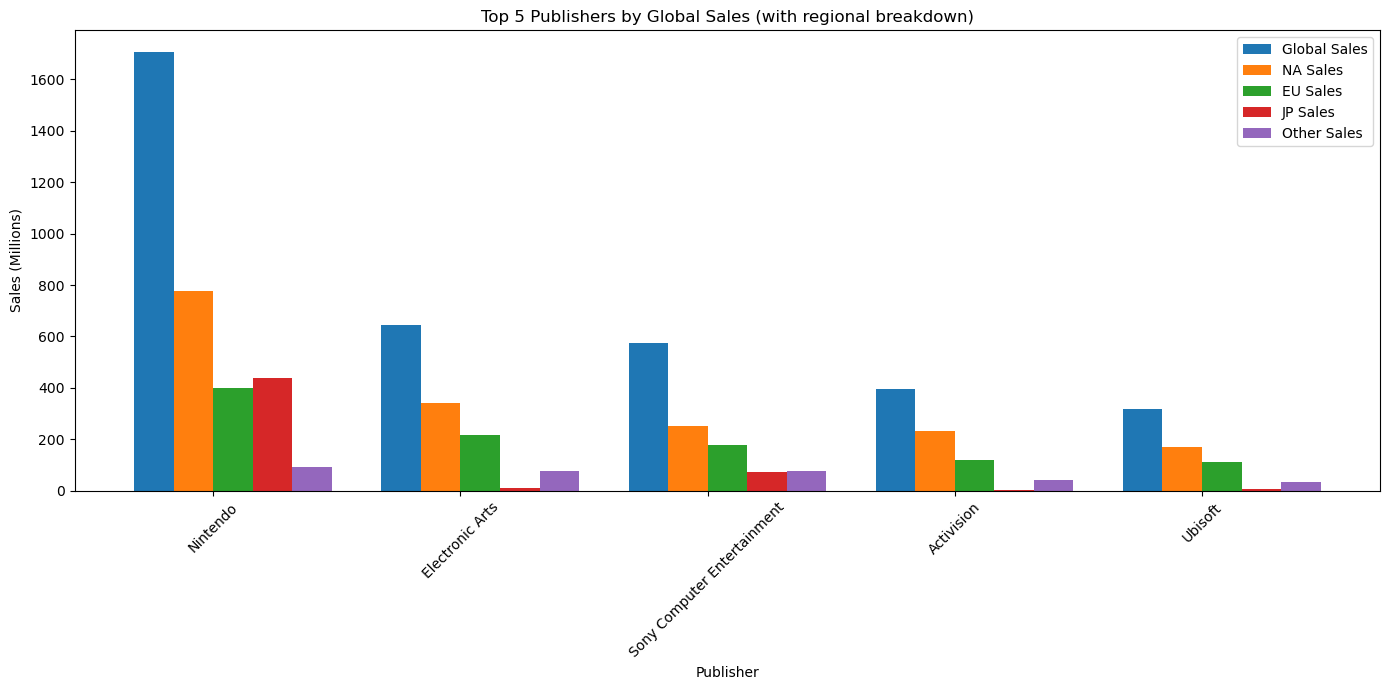

In [56]:
bar_width = 0.16
position = np.arange(len(top_publishers))

plt.figure(figsize=(14, 7))

plt.bar(position, top_publishers['Global_Sales'], bar_width, label='Global Sales')
plt.bar(position + bar_width, top_publishers['NA_Sales'], bar_width, label='NA Sales')
plt.bar(position + 2*bar_width, top_publishers['EU_Sales'], bar_width, label='EU Sales')
plt.bar(position + 3*bar_width, top_publishers['JP_Sales'], bar_width, label='JP Sales')
plt.bar(position + 4*bar_width, top_publishers['Other_Sales'], bar_width, label='Other Sales')

plt.xlabel('Publisher')
plt.ylabel('Sales (Millions)')
plt.title('Top 5 Publishers by Global Sales (with regional breakdown)')
plt.xticks(position + 1.5*bar_width, top_publishers.index, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

The plot above is a vertical bar plot that shows the top 5 video game publishers ordered based on their global sales (blue bar). The rest of the bars the regional breakdown for those companies' sales within different regions contained in the data.

- From the plot above, we can see that the top 5 video game publishers based on sales from highest to lowest is Nintendo, EA, Activision, Sony Computer Entertainment and Ubisoft in that order. 

- The video game market is highly regionally concentrated, with North America and Europe being the largest markets for sales.

- Nintendo’s performance in Japan is a notable exception, this could be reflecting regional brand loyalty and cultural market differences (Nintendo is a Japanese company). This is an exception since Sony is also a Japanese company yet its performance in Japan doesn't nescessary compete with its performance in the the remaining regions. 

Strategic regional focus may influence sales outcomes, with some publishers can potentially perform better where their brand or franchises have a strong presence, however, overall the North American and European market are dominant in terms of sales across the board and so it is best for companies to focus on catering to these markets. 

<h4>Pie chart and Violin Plot - Showing the distribution of game genres with user reviews over the 3rd quartile</h4>

The user review score cut off for being in the top 25% is 8.3



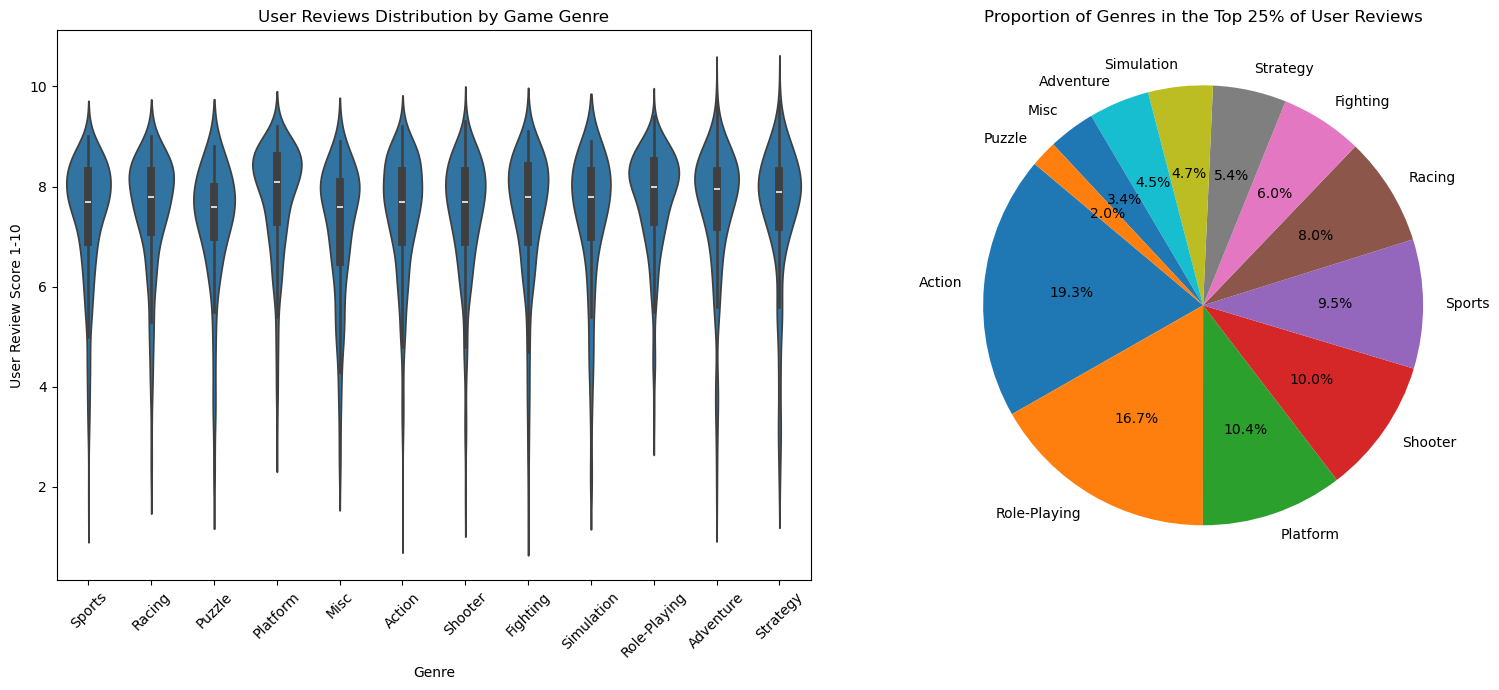

In [59]:
print("The user review score cut off for being in the top 25% is", np.percentile(df['user_review'].dropna(), 75)) 
print("")


genre_counts_Q3 = df[df['user_review'] > np.percentile(df['user_review'].dropna(), 75)]['Genre'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.violinplot(x='Genre', y='user_review', data=df_scatter, ax=axes[0])
axes[0].set_title('User Reviews Distribution by Game Genre')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('User Review Score 1-10')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(genre_counts_Q3, labels=genre_counts_Q3.index,autopct='%1.1f%%', startangle=140)
axes[1].set_title('Proportion of Genres in the Top 25% of User Reviews')
plt.tight_layout()
plt.show()

Shown on the pie chart above looking at the top 25 percentile of games in terms of user reviews e.g., a user review of higher than 8.3. Here, the top 5 out of 12 video game genres listed in terms of distribution are action (19.3%), role-playing (16.7%), platform(10.4%), shooter(10%) and sports (9.5%); in total over 65% of the types of games that are in the top 25% of user reviews fall into one of these 5 genres. Overall, these genres can be thought of as the highly popular genres that is more likely to recieve higher proportions of positive reviews.

- The violin plot shows consistency in review scores across genres. This could imply that user satisfaction levels are relatively similar regardless of genre.
- However, the prevalence of certain genres (like Action, Role-Playing, and Shooter) the 3rd Quartile of reviews indicates that these genres tend to produce more highly-rated or popular games.
- 
These insights could indicate to developers and publishers that more action packed roleplaying, action or shooter games are what people generally rate higher, but also suggest that while genre influences popularity at the top level, user satisfaction levels are relatively stable across genre
- Of course an important thing to also note is that genre most likely is not the defining factor here and there are other factors within these genres, whether that be the quality to the game, a specific publisher being really popular within the genre etc... that affects user reviews rather than the genres..

<h4>Stackplot for  number of games released over time for the 5 most common genres in the top 25% of highest rated games by user review</h4>

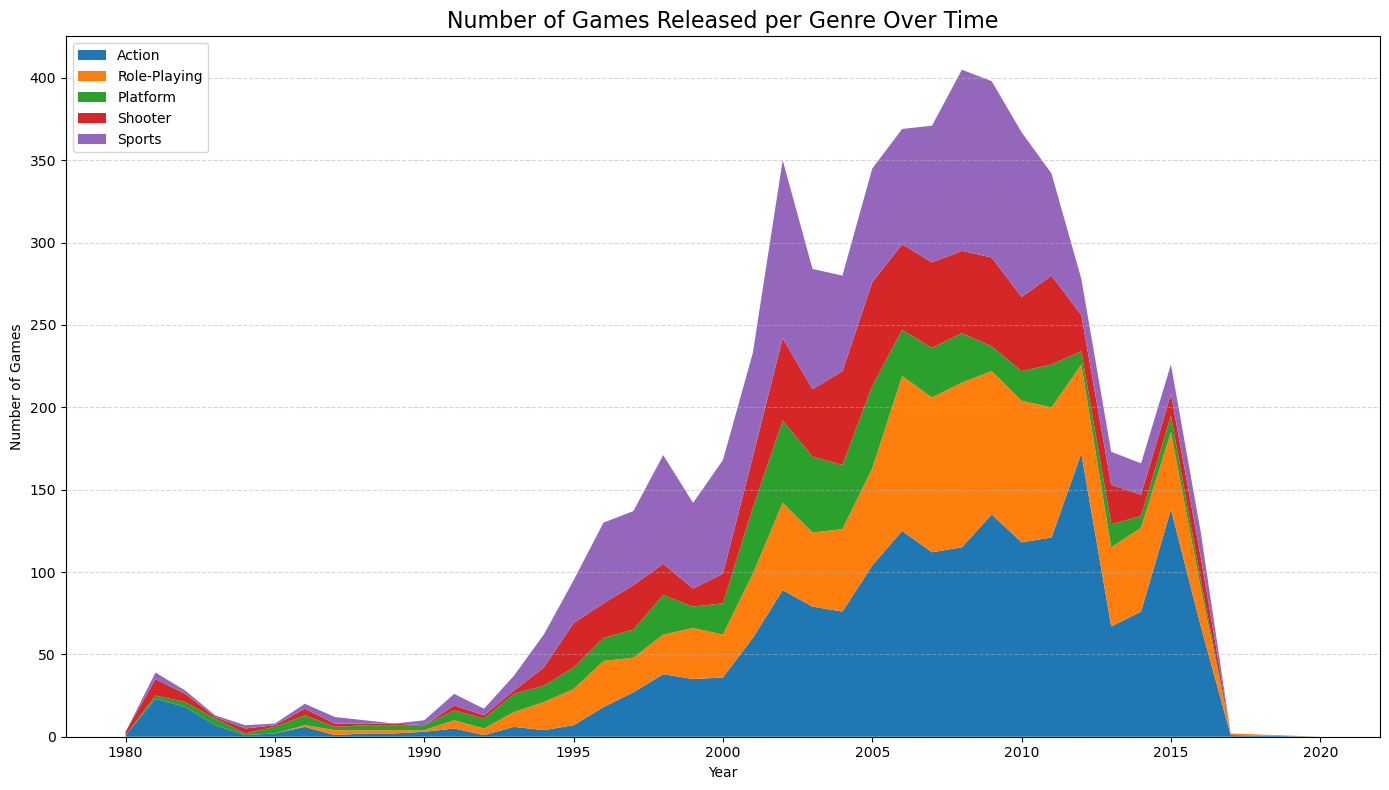

In [62]:
genre_counts_byear = df.groupby(['Year', 'Genre']).size().unstack(fill_value=0)
top_5_genres = genre_counts_Q3.head(5).index.tolist()

plt.figure(figsize=(14, 8))
plt.stackplot(genre_counts_byear.index,
              genre_counts_byear[top_5_genres[0]],
              genre_counts_byear[top_5_genres[1]],
              genre_counts_byear[top_5_genres[2]],
              genre_counts_byear[top_5_genres[3]],
              genre_counts_byear[top_5_genres[4]], labels=top_5_genres)

plt.title('Number of Games Released per Genre Over Time', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.legend(loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The stackplot above plots shows the number of games released per year represented by the different coloured areas overtime. 

Some key take away points from this plot includes: 
- There is a large initial growth in new video game releases in the early 1980s which starts to exponentially increase peaking around 2008-2010.
- There is a noticeable drop after 2015, almost down to zero around 2020. Which reflects the previously established limitation in the dataset with incomplete data after 2010.
- We can see that for the most part there is a positive correlation between the popularity of a genre in terms of user reviews and the number of games released yearly for that genre.
    - The action genre which holds the highest distribution for highly rated games also consistently gets high ammounts of games released yearly compared to the other genres.
    - The second genre with the highest distribution is role-playing which throughout the graph generally has a lower amount of games released yearly.
    - The third and fourth genres for highest rated games, platform and shooter, are close together in terms of distribution for highly rated games; simultaneously the number of games released for these genres seems very close in the stackplot whilst being lower than role-playing and action.  
    - Sports proves to be an exception. The trend of sports games almost seems very seasonal this could be how the popularity of sports games reflect real life sport events. It has sharper peaks compared to the other genres, between 2005-2010 it seems to have more games released in these years compared to shooters and platformers despite being ranked the lowest in terms of user review popularity as shown in the pie chart. 




